# Investigating the impact of the leakage from the Amsterdam Rijnkanaal

Low lying polders adjacent to the Amsterdam Rijnkanaal (ARK) experience more and more
leakage probably from the nearby ARK, which has a water level several meters higher
than that of the polders. The question is what causes this increase of the leagkage occurring
over the last two decades and how can it be solved by use of a layar of a sand-bentione mixture
at the canal bottom.

To investigate this, we'll generate cross section and model them in detail. With this or these
models, different impacts can be simulated and the impact possible measures can be examined for
their effectiveness.

The work is done for Rijkswaterstaat.

@ TO 2026-04-03

In [1]:
import os
import sys
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pdf2image

from mf6lab.Projects.ARK_RWS.src import ARK_fdm

from mf6lab.Projects.ARK_RWS.src.ARK_fdm import (
    geoCodes,
    world_extent,
    CrossSectionDigitizer,
    ImagePicker,
    Dirs,
    plot_result
    )

from tools.fdm.src.mfgrid import Grid

print(sys.executable)

loading mfpath.py
/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/bin/python


# Get the geotop.pdf obtaind from dinoloket.nl

When reading it with pdf2image you get actually two pdfs.
One has the actual cross section and the other the legend and a map.

In [2]:
%matplotlib widget

dirs = Dirs()

geotop_pdf = glob(dirs.dino + '*.pdf')[-1]
geotop1, geotop2 = pdf2image.convert_from_path(geotop_pdf, dpi=300)
geotop1 = np.asarray(geotop1.convert("RGB"))  
geotop2 = np.asarray(geotop2.convert("RGB"))   

# Use the image picker with the legend image to get the legend colors

Instantiate the ImagePicker with the image that holds the map with the legend color boxes.
Then zoom in and click the legend's color boxes in the normal order.
This yields the colors to compare those sampled in the actual cross section with.

Press ENTER to finish with the legend.

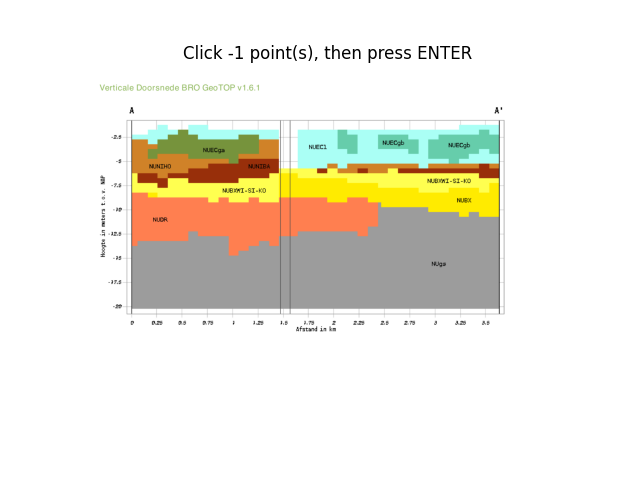

[[255. 255. 255.]]


In [23]:
# ---Instantiate the picker with the image to pick from (image with the legend)
picker = ImagePicker(geotop2)

# --- Zoom before clicking (zoom into legend)
# --- Step 1: Pick legend colors
legend_colors = picker.get_colors(n=-1)
print(legend_colors)

# --- The last legend_color is always [255., 255., 255.] to indicate empty cells later on
# --- Therefore we add a legend index 'none' for this code.
geoCodes.append('none')

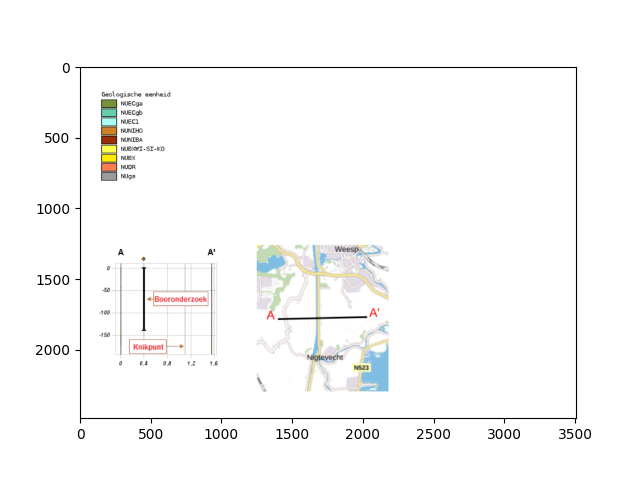

In [28]:
plt.imshow(geotop2)
plt.show()

# With the legend_colors now obtained get the pixel extent of the cross section

Instansiate the ImagePicker one again, but now with the image of the actual cross section.
Zoom in (or presse the image window to the top of the screen to make the window full screen). Then pick the LL nd UR of the cross section of which you know the world coordinates.

Press ENTER when finished. The pixel_exent is thus obtained.

In [ ]:
# --- Initiate a new picker, now with the cross section   
# --- To get the pixel bounding box
picker = ImagePicker(geotop1)

# --- Again, zoom in
# --- Then pick 2 opposite corners, return to finish
extent = picker.get_bbox(n=-1)
print(extent)

# Sample the actual cross section automatically

1. Instantiate the CrossSectionDigitizer with the image of the actual cross section.
1. Make sure it knows its extent (pixel extent)
1. Make sure it knows its world_extent (LL and UR corners)
1. Make sure it knows the legend colors.
1. Make sure it know its grid (Voxel size)

Set the grid by specifying the voxel width dx and the voxel height dz.
These size dx, dz should be obtained from the image. Note that the
real voxel size of geotop is dx=dy=100 m and dz=0.5 m. But when the
the X-sec is neither parallel to the x or y axis, the dx may be different
along the length of the X-section.

The subdivision of the grid is based on the world_extent and the voxel size.

In [ ]:
# --- Fill an array with soil indices where each index is the number of the
# --- legend color boxes in that order (the order clicked before)

# --- Instantiate the CrossSectionDigitizer using the cross section.
digitizer = CrossSectionDigitizer(image=geotop1)

# --- Set pixed extent (see extent obtained above)
digitizer.set_section_bbox(*extent)

# --- Set world extent (given above in world coordinates)
digitizer.set_world_bbox(*world_extent)

# --- Internally set the legend_colors (obtained from clicking the legend)
digitizer.legend_colors = legend_colors

# --- Set voxel size.
digitizer.set_grid(dx=100, dz=0.5)

# Sample the cross section

The digitizer's build_array is used to sample the cross section.

A small area around the centre of each voxel is sampled. Dark colors are removed
to avoid text and lines and the median color (RGB) is sampled. The distance in RGB
space to the legend color is computed and the nearest legend color is found, which
yield the number of the legend box corresponding to the sampled color.

The highest number corresponds to color [255., 255., 255.] meaning no color.

The resulting voxel X-sec array with legend indices can always be converted to
any property that can be linked to the legend. The best way to do this is by
using a pandas DataFrame with the same index as the legend colorboxes.

An mfgrid.Grid object can be used as an alternative grid, but this is not
recommended because it can create artefacts: When the resolution is too fine
these artefacts are caused by lines and text in the image.

Resampling on other grids should be done separately.

In [ ]:
# === Fill in an array of a cross section using  dx and dz and world_extent
arr = digitizer.build_array()

In [ ]:
# --- Show the cross section using imshow, which fills the voxels
plot_result(arr, world_extent)

# --- Add title and save
fig = plt.gcf()
fig.suptitle(f"""{os.path.basename(geotop_pdf)}
                with colors converted to soil-indices
                """)
fig.savefig(os.path.join(dirs.images, f"{os.path.basename(geotop_pdf)}"))

plt.show()

In [4]:
geotop2

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [22]:
geotop2.flatten().mean()

np.float64(249.86787992390975)